Clustering: cluster MachineID based on mean DefectRate, mean Vibration,
mean Temperature, mean Pressure. Label clusters as “High Defect / High
Vibration” etc. Output cluster summary


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_excel('/content/drive/MyDrive/internship /QUALITY & DEFECT REDUCTION.xlsx')

df.head()

,Timestamp,MachineID,Plant,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
0,2025-01-01 00:00:00,142,Plant_B,77.474270,2.604480,23.438160,315.443998,52,4,0
1,2025-01-01 01:00:00,124,Plant_C,72.435288,6.240213,30.236166,300.579876,89,1,0
2,2025-01-01 02:00:00,103,Plant_A,59.063863,6.470758,32.778778,240.961506,194,0,0
3,2025-01-01 03:00:00,108,Plant_C,63.859148,3.646682,26.077120,206.954154,190,2,0
4,2025-01-01 04:00:00,100,Plant_B,76.799275,5.261242,33.432417,259.130150,173,8,1


In [4]:
df['DefectRate'] = df['DefectCount'] / df['ProductionUnits']

In [5]:
machine_df = df.groupby('MachineID').agg({
    'DefectRate': 'mean',
    'Vibration': 'mean',
    'Temperature': 'mean',
    'Pressure': 'mean'
}).reset_index()

machine_df.head()

,MachineID,DefectRate,Vibration,Temperature,Pressure
0,100,0.028896,5.119509,69.729144,30.550820
1,101,0.027600,4.937900,70.082934,30.169352
2,102,0.026264,4.948084,69.981160,29.947623
3,103,0.027602,5.048506,70.219775,30.119664
4,104,0.028507,5.023351,69.679257,29.725638


In [6]:
features = ['DefectRate', 'Vibration', 'Temperature', 'Pressure']
X = machine_df[features]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
machine_df['Cluster'] = kmeans.fit_predict(X_scaled)

machine_df.head()

,MachineID,DefectRate,Vibration,Temperature,Pressure,Cluster
0,100,0.028896,5.119509,69.729144,30.550820,2
1,101,0.027600,4.937900,70.082934,30.169352,1
2,102,0.026264,4.948084,69.981160,29.947623,1
3,103,0.027602,5.048506,70.219775,30.119664,0
4,104,0.028507,5.023351,69.679257,29.725638,1


In [9]:
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

centers

,DefectRate,Vibration,Temperature,Pressure
0,0.027661,5.004555,70.566061,30.006705
1,0.027693,5.000364,69.842391,29.884812
2,0.028874,4.973216,69.660755,30.254396


In [10]:
def label_cluster(row):
    label = []

    if row['DefectRate'] > machine_df['DefectRate'].mean():
        label.append('High Defect')
    else:
        label.append('Low Defect')

    if row['Vibration'] > machine_df['Vibration'].mean():
        label.append('High Vibration')
    else:
        label.append('Low Vibration')

    return " / ".join(label)

# Apply labeling using cluster centers
cluster_labels = centers.apply(label_cluster, axis=1)

cluster_labels

,0
0,Low Defect / High Vibration
1,Low Defect / High Vibration
2,High Defect / Low Vibration


In [11]:
cluster_label_map = dict(enumerate(cluster_labels))

machine_df['Cluster_Label'] = machine_df['Cluster'].map(cluster_label_map)

machine_df.head()

,MachineID,DefectRate,Vibration,Temperature,Pressure,Cluster,Cluster_Label
0,100,0.028896,5.119509,69.729144,30.550820,2,High Defect / Low Vibration
1,101,0.027600,4.937900,70.082934,30.169352,1,Low Defect / High Vibration
2,102,0.026264,4.948084,69.981160,29.947623,1,Low Defect / High Vibration
3,103,0.027602,5.048506,70.219775,30.119664,0,Low Defect / High Vibration
4,104,0.028507,5.023351,69.679257,29.725638,1,Low Defect / High Vibration


In [12]:
summary = machine_df.groupby('Cluster_Label').agg({
    'MachineID': 'count',
    'DefectRate': 'mean',
    'Vibration': 'mean',
    'Temperature': 'mean',
    'Pressure': 'mean'
}).rename(columns={'MachineID': 'Machine_Count'})

summary

,Machine_Count,DefectRate,Vibration,Temperature,Pressure
Cluster_Label,,,,,
High Defect / Low Vibration,6,0.028874,4.973216,69.660755,30.254396
Low Defect / High Vibration,44,0.027681,5.001983,70.121991,29.931907


In [13]:
summary.sort_values(by='DefectRate', ascending=False)

,Machine_Count,DefectRate,Vibration,Temperature,Pressure
Cluster_Label,,,,,
High Defect / Low Vibration,6,0.028874,4.973216,69.660755,30.254396
Low Defect / High Vibration,44,0.027681,5.001983,70.121991,29.931907


In [14]:
import matplotlib.pyplot as plt

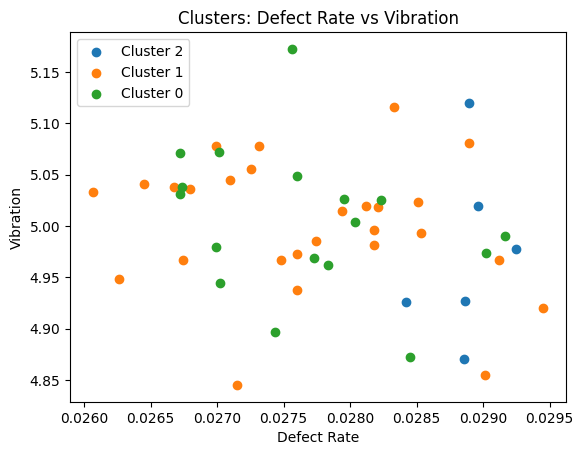

In [15]:
plt.figure()

for cluster in machine_df['Cluster'].unique():
    subset = machine_df[machine_df['Cluster'] == cluster]
    plt.scatter(subset['DefectRate'], subset['Vibration'], label=f'Cluster {cluster}')

plt.xlabel('Defect Rate')
plt.ylabel('Vibration')
plt.title('Clusters: Defect Rate vs Vibration')
plt.legend()

plt.show()

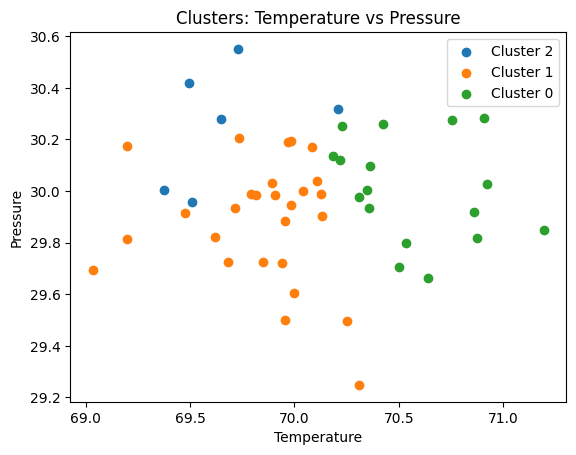

In [16]:
plt.figure()

for cluster in machine_df['Cluster'].unique():
    subset = machine_df[machine_df['Cluster'] == cluster]
    plt.scatter(subset['Temperature'], subset['Pressure'], label=f'Cluster {cluster}')

plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.title('Clusters: Temperature vs Pressure')
plt.legend()

plt.show()

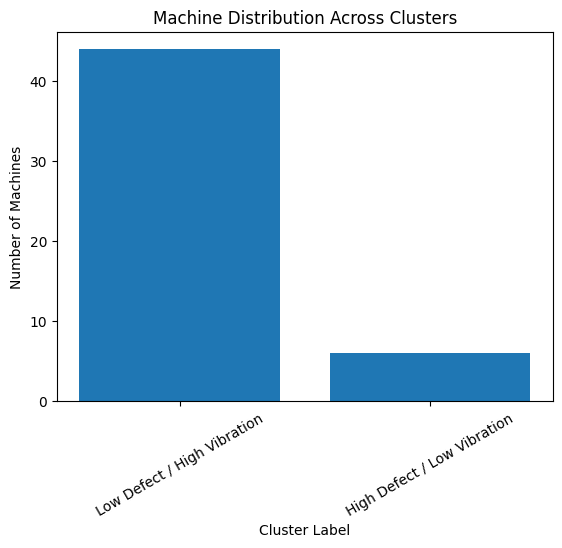

In [17]:
cluster_counts = machine_df['Cluster_Label'].value_counts()

plt.figure()
plt.bar(cluster_counts.index, cluster_counts.values)

plt.xlabel('Cluster Label')
plt.ylabel('Number of Machines')
plt.title('Machine Distribution Across Clusters')

plt.xticks(rotation=30)
plt.show()

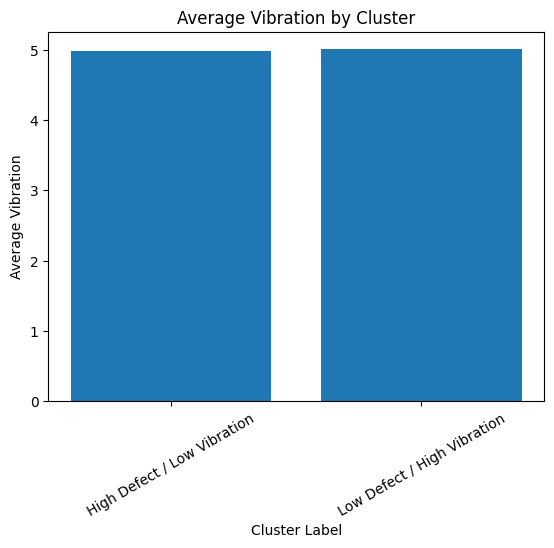

In [18]:
avg_vibration = machine_df.groupby('Cluster_Label')['Vibration'].mean()

plt.figure()
plt.bar(avg_vibration.index, avg_vibration.values)

plt.xlabel('Cluster Label')
plt.ylabel('Average Vibration')
plt.title('Average Vibration by Cluster')

plt.xticks(rotation=30)
plt.show()

Clustering helped transform raw machine data into actionable insights, enabling early detection of high-defect machines and improving overall production quality